In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

from numpy.random import normal, uniform

import tqdm

import random
from random import randint

import torch
import torch.nn as nn
import torch.fft as fft
from torch import cdist

import math

import random
import h5py

In [2]:
torch.set_default_dtype(torch.float64)


In [3]:
width = 0.015
depth = 0.01
height = 0.002
x_center = 0.0
y_center = 0.0
z_center = 0.0

x_min = x_center - width / 2
x_max = x_center + width / 2
y_min = y_center - depth / 2
y_max = y_center + depth / 2
z_min = z_center - height / 2
z_max = z_center + height / 2

In [4]:
device = "cpu"
n_x = 31
n_y = 21
n_z = 5
x = torch.linspace(x_min, x_max, n_x, device=device)
y = torch.linspace(y_min, y_max, n_y, device=device)
z = torch.linspace(z_min, z_max, n_z, device=device)

In [5]:
X, Y, Z = torch.meshgrid(x, y, z)


boundary_mask = (X == x[0]) | (X == x[-1]) | (Y == y[0]) | (Y == y[-1]) | (Z == z[0]) | (Z == z[-1])
# Flatten the mask
boundary_indices = torch.where(boundary_mask.flatten())[0]

# Convert to torch tensor to obtain indices of interior points
interior_mask = ~boundary_mask.flatten()
interior_indices = torch.where(interior_mask)[0]

#Interior indices, then boundary indices
rearranged_indices = torch.concatenate((interior_indices,boundary_indices),axis=0)
grid = torch.concatenate((X.flatten()[:,None],Y.flatten()[:,None],Z.flatten()[:,None]),axis=1)
#mesh_points = torch.load("mesh_points")


X_domain_tot = grid[interior_indices]

N_domain_tot = X_domain_tot.shape[0]
N_tot = grid.shape[0]
N_boundary_tot = N_tot-N_domain_tot

/opt/anaconda3/envs/pytorch_env/lib/python3.12/site-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/_temp/anaconda/conda-bld/pytorch_1729646995093/work/aten/src/ATen/native/TensorShape.cpp:3596.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [6]:
is_x_min = grid[:, 0] == x_min
is_x_max = grid[:, 0] == x_max
is_y_min = grid[:, 1] == y_min
is_y_max = grid[:, 1] == y_max
is_z_min = grid[:, 2] == z_min
is_z_max = grid[:, 2] == z_max
is_z_below = X_domain_tot[:, 2] == z[-2]


# All boundary points (matches what you had before)
boundary_mask = is_x_min | is_x_max | is_y_min | is_y_max | is_z_min | is_z_max

# Γ_top, Γ_bottom
gamma_top_mask    = boundary_mask & is_z_max
gamma_bottom_mask = boundary_mask & is_z_min
gamma_below_mask = is_z_below

# Γ_side = ∂Ω \ (Γ_top ∪ Γ_bottom)
gamma_side_mask = boundary_mask & ~(is_z_min | is_z_max)

In [7]:
# Raw side walls (ignoring top/bottom, already enforced above)
side_x_min = gamma_side_mask & is_x_min
side_x_max = gamma_side_mask & is_x_max
side_y_min = gamma_side_mask & is_y_min
side_y_max = gamma_side_mask & is_y_max

# Edges where two side faces intersect (still in Γ_side because z is not extreme)
edge_xmin_ymin = gamma_side_mask & is_x_min & is_y_min
edge_xmin_ymax = gamma_side_mask & is_x_min & is_y_max
edge_xmax_ymin = gamma_side_mask & is_x_max & is_y_min
edge_xmax_ymax = gamma_side_mask & is_x_max & is_y_max

In [8]:
# Start from points that are only on one side face (no edge)
only_x_min = side_x_min & ~(is_y_min | is_y_max)
only_x_max = side_x_max & ~(is_y_min | is_y_max)
only_y_min = side_y_min & ~(is_x_min | is_x_max)
only_y_max = side_y_max & ~(is_x_min | is_x_max)

# Apply your edge allocation rules
gamma_side_x_min_mask = only_x_min | edge_xmin_ymin
gamma_side_x_max_mask = only_x_max | edge_xmax_ymax
gamma_side_y_min_mask = only_y_min | edge_xmax_ymin
gamma_side_y_max_mask = only_y_max | edge_xmin_ymax

In [9]:
gamma_top_idx    = torch.where(gamma_top_mask)[0]
gamma_bottom_idx = torch.where(gamma_bottom_mask)[0]
gamma_below_idx = torch.where(gamma_below_mask)[0]

gamma_side_x_min_idx = torch.where(gamma_side_x_min_mask)[0]
gamma_side_x_max_idx = torch.where(gamma_side_x_max_mask)[0]
gamma_side_y_min_idx = torch.where(gamma_side_y_min_mask)[0]
gamma_side_y_max_idx = torch.where(gamma_side_y_max_mask)[0]

In [10]:
Gamma_bottom = grid[gamma_bottom_mask]     # z == z_min
Gamma_top    = grid[gamma_top_mask]        # z == z_max

Gamma_side_x_min = grid[gamma_side_x_min_mask]  # x == x_min, priority edges included
Gamma_side_x_max = grid[gamma_side_x_max_mask]  # x == x_max

Gamma_side_x = torch.vstack([Gamma_side_x_min,Gamma_side_x_max])

Gamma_side_y_min = grid[gamma_side_y_min_mask]  # y == y_min
Gamma_side_y_max = grid[gamma_side_y_max_mask]  # y == y_max

Gamma_side_y = torch.vstack([Gamma_side_y_min,Gamma_side_y_max])

In [11]:
N_top = len(Gamma_top)
N_bottom = len(Gamma_bottom)

N_side_x_min = len(Gamma_side_x_min)
N_side_x_max = len(Gamma_side_x_max)
N_side_x = N_side_x_max+N_side_x_min

N_side_y_min = len(Gamma_side_y_min)
N_side_y_max = len(Gamma_side_y_max)
N_side_y = N_side_y_max+N_side_y_min

N_matrix_tot = N_tot+4*N_domain_tot

In [12]:
X_boundary_tot = torch.vstack([Gamma_side_x,Gamma_side_y,Gamma_bottom,Gamma_top])
grid = torch.vstack([X_domain_tot,X_boundary_tot])

In [13]:
def p(T):
    T = torch.as_tensor(T, dtype=torch.float64)
    c1 = T < 4.0
    c2 = T < 93.0
    c3 = T < 1700.0

    const_4 = 7930.967 + 0.03300298*4.0 - 9.663581e-4*4.0**2 - 2.917178e-6*4.0**3
    poly_cubic = 7930.967 + 0.03300298*T - 9.663581e-4*T**2 - 2.917178e-6*T**3
    poly_quartic = 7945.333 - 0.1981948*T - 3.713764e-4*T**2 + 2.213069e-7*T**3 - 5.128456e-11*T**4
    const_1700 = 7945.333 - 0.1981948*1700.0 - 3.713764e-4*1700.0**2 + 2.213069e-7*1700.0**3 - 5.128456e-11*1700.0**4
    

    return torch.where(
        c1, torch.tensor(const_4, dtype=T.dtype, device=T.device),
        torch.where(c2, poly_cubic,
            torch.where(c3, poly_quartic,
                torch.tensor(const_1700, dtype=T.dtype, device=T.device)
            )
        )
    )
    

def C(T):
    """
    Piecewise Cp(T) in torch, matching the FEniCS conditional/lt semantics:
      T < 4      : constant Cp evaluated at 4
      4 ≤ T < 14 : quartic P1(T)
      14 ≤ T < 47: quartic P2(T)
      47 ≤ T <128: quartic P3(T)
      128≤ T <310: quartic P4(T)
      310≤ T <1311: quintic P5(T)
      T ≥ 1311   : constant P5 evaluated at 1311
    """
    T = torch.as_tensor(T)
    if not torch.is_floating_point(T):
        T = T.to(torch.get_default_dtype())
    dtype, device = T.dtype, T.device
    c = lambda v: torch.as_tensor(v, dtype=dtype, device=device)

    # Polynomials
    P1 = 4.80349978 - 1.97398861*T + 0.433444409*T**2 - 0.0314324757*T**3 + 8.32403453e-4*T**4
    P2 = -0.224295746 + 0.760568357*T - 4.00750758e-2*T**2 + 2.18176061e-3*T**3 - 1.83602372e-5*T**4
    P3 = 8.9262753 - 2.90098686*T + 0.147079315*T**2 - 0.00125489708*T**3 + 3.41401137e-6*T**4
    P4 = 270.215021 - 1.21051111*T + 2.15156635e-2*T**2 - 7.51184063e-5*T**3 + 8.13679634e-8*T**4
    P5 = (109.207295 + 2.5717751*T - 6.52809855e-3*T**2 + 7.78752439e-6*T**3
          - 4.16791252e-9*T**4 + 8.09061335e-13*T**5)

    # Boundary constants (clamping)
    Cp_at_4 = 4.80349978 - 1.97398861*4.0 + 0.433444409*4.0**2 - 0.0314324757*4.0**3 + 8.32403453e-4*4.0**4
    Cp_at_1311 = (109.207295 + 2.5717751*1311.0 - 6.52809855e-3*1311.0**2 + 7.78752439e-6*1311.0**3
                  - 4.16791252e-9*1311.0**4 + 8.09061335e-13*1311.0**5)

    return torch.where(T < 4.0, c(Cp_at_4),
           torch.where(T < 14.0, P1,
           torch.where(T < 47.0, P2,
           torch.where(T < 128.0, P3,
           torch.where(T < 310.0, P4,
           torch.where(T < 1311.0, P5, c(Cp_at_1311)))))))


def k(T):
    """
    Piecewise k(T) in torch, matching the FEniCS conditional/lt semantics:
      T < 1      : constant k evaluated at 1
      1 ≤ T < 45 : quartic Q1(T)
      45≤ T <283 : quartic Q2(T)
      283≤ T <887: quartic Q3(T)
      T ≥ 887    : constant Q3 evaluated at 887
    """
    T = torch.as_tensor(T)
    if not torch.is_floating_point(T):
        T = T.to(torch.get_default_dtype())
    dtype, device = T.dtype, T.device
    c = lambda v: torch.as_tensor(v, dtype=dtype, device=device)

    # Polynomials
    Q1 = (-0.03740871 + 0.06460546*T + 0.003720604*T**2
          - 8.390067e-5*T**3 + 6.006594e-7*T**4)
    Q2 = (-1.031521 + 0.1813807*T - 0.001088656*T**2
          + 3.411681e-6*T**3 - 3.988389e-9*T**4)
    Q3 = (-1.258169 + 0.1023945*T - 2.189547e-4*T**2
          + 2.312931e-7*T**3 - 8.903937e-11*T**4)

    # Boundary constants (clamping)
    k_at_1 = (-0.03740871 + 0.06460546*1.0 + 0.003720604*1.0**2
              - 8.390067e-5*1.0**3 + 6.006594e-7*1.0**4)
    k_at_887 = (-1.258169 + 0.1023945*887.0 - 2.189547e-4*887.0**2
                + 2.312931e-7*887.0**3 - 8.903937e-11*887.0**4)


    return torch.where(T < 1.0, c(k_at_1),
           torch.where(T < 45.0, Q1,
           torch.where(T < 283.0, Q2,
           torch.where(T < 887.0, Q3, c(k_at_887)))))
    
def k_prime(T):
    """
    Piecewise first derivative of k(T) wrt T.
      T < 1        : 0
      1 ≤ T < 45   : d/dT of Q1(T)
      45 ≤ T < 283 : d/dT of Q2(T)
      283 ≤ T < 887: d/dT of Q3(T)
      T ≥ 887      : 0
    """
    if isinstance(T, torch.Tensor):
        if not torch.is_floating_point(T):
            T = T.to(torch.get_default_dtype())
    else:
        T = torch.as_tensor(T, dtype=torch.get_default_dtype())

    # Segment derivatives
    dQ1 = (0.06460546
           + 0.007441208*T
           - 2.5170201e-4*T**2
           + 2.4026376e-6*T**3)

    dQ2 = (0.1813807
           - 0.002177312*T
           + 1.0235043e-5*T**2
           - 1.5953556e-8*T**3)

    dQ3 = (0.1023945
           - 4.379094e-4*T
           + 6.938793e-7*T**2
           - 3.5615748e-10*T**3)

    zero = torch.zeros_like(T)
    return torch.where(T < 1.0, zero,
           torch.where(T < 45.0, dQ1,
           torch.where(T < 283.0, dQ2,
           torch.where(T < 887.0, dQ3, zero))))



In [14]:
def generate_zigzag_path_torch(length_x, length_y, linespace, *,
                               dtype=torch.float64, device="cpu", return_indices=False):
    """
    Zigzag (boustrophedon) traversal of a rectilinear grid with spacing `linespace`
    over the rectangle [-length_x/2, +length_x/2] × [-length_y/2, +length_y/2].

    Returns:
      paths_x, paths_y : 1D tensors of length (nx+1)*(ny+1), visiting each grid node once
      If return_indices=True, also returns (i_order, j_order) integer indices.
    """
    # number of intervals along each axis (rounded; require near-integer)
    nx = int(round(length_x / linespace))
    ny = int(round(length_y / linespace))
    tol = 1e-12
    if abs(nx * linespace - length_x) > tol or abs(ny * linespace - length_y) > tol:
        raise ValueError("length_x/length_y must be (near) integer multiples of linespace.")

    # grid indices
    i = torch.arange(nx + 1, device=device)
    j = torch.arange(ny + 1, device=device)
    I, J = torch.meshgrid(i, j, indexing="ij")   # shapes (nx+1, ny+1)

    # physical coordinates
    x0 = -length_x / 2.0
    y0 = -length_y / 2.0
    X = x0 + I.to(dtype) * linespace
    Y = y0 + J.to(dtype) * linespace

    # zigzag order: sort by anti-diagonal k = i + j; within each k,
    # even k -> i ascending; odd k -> i descending
    K = I + J                            # anti-diagonal index
    P = torch.where((K % 2) == 0, I, -I) # secondary key: i or -i
    # build a combined integer key for a single argsort (lexicographic on (K, P))
    stride = 2 * (nx + 1) + 1
    key = (K.long() * stride + (P.long() + (nx)))  # ensure non-negative

    order = torch.argsort(key.reshape(-1))
    paths_x = X.reshape(-1)[order]
    paths_y = Y.reshape(-1)[order]

    if return_indices:
        i_order = I.reshape(-1)[order]
        j_order = J.reshape(-1)[order]
        return paths_x, paths_y, i_order, j_order
    return paths_x, paths_y

In [15]:
length_x = 0.004
length_y = 0.004
num_interval = 2 # Change to adjust the linespace of laser beam (1,2,3,4,5,...)
linespace = length_y / num_interval
paths_x, paths_y = generate_zigzag_path_torch(length_x, length_y, linespace)


In [16]:
heat_sol = torch.load('heat_sol')
heat_top_bc = torch.load('heat_top_bc')
heat_dx = torch.load('heat_dx')
heat_dy = torch.load('heat_dy')
heat_dz = torch.load('heat_dz')
heat_Lap = torch.load('heat_Lap')

/var/folders/7x/mpmr_n_96hv_7fkxygr63wg80000gn/T/ipykernel_9132/3990178024.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  heat_sol = torch.load('heat_sol')
/var/folders

In [17]:
M_t=128
T0 = 293.15

num_realizations = 100
heat_int = heat_sol[:,interior_indices,:]
heat_dx_int = heat_dx[:,interior_indices,:]
heat_dy_int = heat_dy[:,interior_indices,:]
heat_dz_int = heat_dz[:,interior_indices,:]
heat_Lap_int = heat_Lap[:,interior_indices,:]

zeros_Neumann = torch.zeros(num_realizations,N_side_x+N_side_y,M_t+1)
bottom_BC = T0*torch.ones(num_realizations,N_bottom,M_t+1)

prekernel = torch.hstack([heat_int,zeros_Neumann,bottom_BC,heat_top_bc,heat_dx_int,heat_dy_int,heat_dz_int,heat_Lap_int])

In [18]:
prekernel.shape

torch.Size([100, 9867, 129])

In [62]:
used_solutions = 1

K_used = prekernel[:used_solutions]      

N, K_dim, N_T = K_used.shape   

#N=100, K_dim=9867, N_T = 129

       

# K_list = torch.zeros(K_dim,K_dim,N_T)

# for i in range(N_T):
#     K_list[:,:,i] = K_used[:,:,i].T@K_used[:,:,i]/used_solutions

In [63]:
# # Flatten (k, l) into one axis → shape (K_dim * L, N)
# # so each column is the "feature vector" for index i
# feat = K_use.reshape(K_dim * L, N)  

# # Gram matrix: K_Mat[i,j] = sum_{k,l} feat_{(k,l),i} * feat_{(k,l),j}
# K_Mat = (feat.T @ feat)/(used_solutions*(M_t+1)) 

In [64]:
def smooth_zigzag_flux(x, t, paths_x, paths_y, velocity, power, sigma,
                       *, dtype=torch.float64, device=None, return_focus=False):
    """
    Gaussian flux centered at a point that moves along a polyline at constant speed.

    Args
    ----
    x : (..., 2) query points (x1, x2); tensor/ndarray/list
    t : float or 0-D/1-D tensor (time)
    paths_x, paths_y : (N,) path coordinates (at least N>=2)
    velocity : float (units of length/time) along the path
    power : float (laser power)
    sigma : float (beam sigma; matches your original formula)
    dtype, device : optional tensor dtype/device
    return_focus : if True, also return the current focus point (x_f, y_f)

    Returns
    -------
    flux : (...) tensor (same leading shape as x[...,0])
    (optional) focus : (2,) tensor with current focus coordinates
    """

    # --- to torch ---
    px = torch.as_tensor(paths_x, dtype=dtype, device=device)
    py = torch.as_tensor(paths_y, dtype=dtype, device=px.device)
    if px.numel() < 2:
        raise ValueError("Path must contain at least two points.")

    P = torch.stack([px, py], dim=-1)     # (N, 2)
    x = torch.as_tensor(x, dtype=dtype, device=P.device)
    if x.shape[-1] != 2:
        raise ValueError("x must have shape (..., 2)")

    t = torch.as_tensor(t, dtype=dtype, device=P.device)

    # --- segment lengths & cumulative arc-length ---
    seg = P[1:] - P[:-1]                  # (N-1, 2)
    seg_len = torch.linalg.norm(seg, dim=-1)  # (N-1,)
    total_len = seg_len.sum()
    if total_len <= 0:
        # All points coincident → fixed focus at P[0]
        focus = P[0]
    else:
        # distance traveled along the path (mod total length)
        s = torch.remainder(t * velocity, total_len)  # scalar tensor

        # find segment index k with cumulative >= s
        cum = torch.cumsum(seg_len, dim=0)            # (N-1,)
        k = torch.searchsorted(cum, s).item()         # integer in [0, N-2]

        s_prev = cum[k-1] if k > 0 else cum.new_zeros(())
        Lk = seg_len[k]
        # guard against zero-length segment
        alpha = (s - s_prev) / (Lk + (Lk == 0).to(dtype) * 1.0)
        alpha = torch.clamp(alpha, 0.0, 1.0)

        focus = P[k] + alpha * (P[k+1] - P[k])        # (2,)

    # --- Gaussian flux at distance from focus ---
    # Original formula:
    # flux = (2*power) / (π * (2*sigma)^2) * exp(-2 * r^2 / (2*sigma)^2)
    # = power / (2πσ^2) * exp(- r^2 / (2σ^2))
    diff = x - focus
    r2 = (diff**2).sum(dim=-1)
    denom = math.pi * (2.0 * sigma)**2
    flux = (2.0 * power) / denom * torch.exp(-2.0 * r2 / (2.0 * sigma)**2)
    flux = flux.float()

    return (flux, focus) if return_focus else flux

In [65]:
# after assembling K_Mat (float64)

# factorization for *this* K
sigma_beam = 10**-4

In [66]:

def J_w(z, L, y0, y1, y2, y3, y4,y_top, C, p, k, k_prime, t, dt=5e-4):
    z  = z.to(device=L.device, dtype=L.dtype)
    y0 = y0.to(device=L.device, dtype=L.dtype)
    y1 = y1.to(device=L.device, dtype=L.dtype)
    y2 = y2.to(device=L.device, dtype=L.dtype)
    y3 = y3.to(device=L.device, dtype=L.dtype)
    y4 = y4.to(device=L.device, dtype=L.dtype)

    # Interior T^{n+1}
    z0 = z[:N_domain_tot]

    # Boundary vector
    bdy_g = torch.zeros(N_boundary_tot, device=L.device, dtype=L.dtype)
    bdy_g[:N_side_x + N_side_y] = 0.0               # side Neumann 0
    bdy_g[N_side_x+N_side_y:N_side_x+N_side_y+N_bottom] = T0  # bottom Dirichlet
    q = smooth_zigzag_flux(Gamma_top[:,:2],t,paths_x=paths_x,paths_y=paths_y,velocity=0.3, power=10.0, sigma=sigma_beam)
    bdy_g[N_side_x+N_side_y+N_bottom:] = q/k(y_top)        # top Neumann q=0

    # Interior gradients at time n+1
    z1 = z[N_domain_tot:2*N_domain_tot]
    z2 = z[2*N_domain_tot:3*N_domain_tot]
    z3 = z[3*N_domain_tot:4*N_domain_tot]

    grad_sq = y1**2 + y2**2 + y3**2

    kz   = k(y0)
    kpz  = k_prime(y0)
    pz   = p(y0)
    Cz   = C(y0)

    z4 = (1.0 / kz) * (
        2.0 * pz * Cz * (z0 - y0) / dt
        - kz * y4
        - kpz * grad_sq
        - kpz * (z1*y1 + z2*y2 + z3*y3)
    )

    zz = torch.cat((z0, bdy_g, z1, z2, z3, z4), dim=0)  # (N_matrix_tot,)
    #temp = L.T @ zz
    
        # Solve K_reg * y = zz using the Cholesky factor L (K_reg = L L^T)
    rhs = zz.unsqueeze(1)                           # (N, 1)
    y   = torch.cholesky_solve(rhs, L, upper=False) # (N, 1), y = K_reg^{-1} zz
    J = (zz.unsqueeze(0) @ y).squeeze()             # scalar
    #return temp.dot(temp)
    return J


def Hessian_w(z, L, y0, y1, y2, y3, C, p, k, k_prime, dt=5e-4):
    z = z.to(device=L.device, dtype=L.dtype)
    y0 = y0.to(device=L.device, dtype=L.dtype)
    y1 = y1.to(device=L.device, dtype=L.dtype)
    y2 = y2.to(device=L.device, dtype=L.dtype)
    y3 = y3.to(device=L.device, dtype=L.dtype)

    total_rows = N_matrix_tot
    mtx = torch.zeros((total_rows, 4*N_domain_tot), device=L.device, dtype=L.dtype)

    I = torch.eye(N_domain_tot, device=L.device, dtype=L.dtype)

    # Identity blocks for z0,z1,z2,z3
    mtx[:N_domain_tot, :N_domain_tot] = I
    mtx[N_tot:N_tot+N_domain_tot, N_domain_tot:2*N_domain_tot] = I
    mtx[N_tot+N_domain_tot:N_tot+2*N_domain_tot, 2*N_domain_tot:3*N_domain_tot] = I
    mtx[N_tot+2*N_domain_tot:N_tot+3*N_domain_tot, 3*N_domain_tot:4*N_domain_tot] = I
    

    kz  = k(y0)
    kpz = k_prime(y0)
    pz  = p(y0)
    Cz  = C(y0)

    # derivatives of z4 wrt z0,z1,z2,z3
    mtx[N_tot+3*N_domain_tot:, :N_domain_tot]              = torch.diag( (2.0 * pz * Cz) / (kz * dt) )
    mtx[N_tot+3*N_domain_tot:, N_domain_tot:2*N_domain_tot] = torch.diag( -kpz * y1 / kz )
    mtx[N_tot+3*N_domain_tot:, 2*N_domain_tot:3*N_domain_tot] = torch.diag( -kpz * y2 / kz )
    mtx[N_tot+3*N_domain_tot:, 3*N_domain_tot:4*N_domain_tot] = torch.diag( -kpz * y3 / kz )
    
    Y = torch.cholesky_solve(mtx, L, upper=False)
    H = 2.0 * (mtx.T @ Y)   # shape (4N_dom, 4N_dom)
    #S = L.T @ mtx
    #return 2.0 * (S.t() @ S)
    return H


def grad_J_w(z, L, y0, y1, y2, y3, y4, y_top, C, p, k, k_prime,t, dt=5e-4):
    L = L.to(z.device, dtype=z.dtype)
    z = z.detach().clone().requires_grad_(True)
    loss = J_w(z, L, y0, y1, y2, y3, y4, y_top, C, p, k, k_prime,t, dt)
    grad_z, = torch.autograd.grad(loss, z)
    return grad_z

In [67]:
def extend_T_below_to_boundary(T_below_int, n_x, n_y):
    """
    T_below_int: (n_x-2, n_y-2) interior second-top layer
    returns T_below_full: (n_x, n_y) including boundary, using zero-flux mirroring in x,y.
    """
    device = T_below_int.device
    dtype  = T_below_int.dtype

    T_below_full = torch.zeros((n_x, n_y), device=device, dtype=dtype)

    # put interior in place
    T_below_full[1:-1, 1:-1] = T_below_int

    # side Neumann (zero flux) -> mirror neighbors
    T_below_full[0,    1:-1] = T_below_full[1,    1:-1]   # left
    T_below_full[-1,   1:-1] = T_below_full[-2,   1:-1]   # right
    T_below_full[1:-1, 0   ] = T_below_full[1:-1, 1   ]   # front
    T_below_full[1:-1, -1  ] = T_below_full[1:-1, -2  ]   # back

    # corners: average of adjacent edges (or just copy one)
    T_below_full[0, 0]      = T_below_full[1, 1]
    T_below_full[0, -1]     = T_below_full[1, -2]
    T_below_full[-1, 0]     = T_below_full[-2, 1]
    T_below_full[-1, -1]    = T_below_full[-2,-2]

    return T_below_full


def newton_top_from_Tbelow(T_below_full, q_top, dz, max_iter=5, tol=1e-6):
    """
    Solve for T_top on the entire top plane given:
        k(T_top) * (T_top - T_below_full)/dz = q_top   (your + sign convention)
    q_top, T_below_full: (n_x, n_y)
    Returns T_top: (n_x, n_y)
    """
    device = T_below_full.device
    dtype  = T_below_full.dtype

    # initial guess: start from T_below
    T_top = T_below_full.clone()

    for _ in range(max_iter):
        k_val  = k(T_top)         # your k(T)
        kp_val = k_prime(T_top)   # derivative wrt T

        # F(T_top) = k(T_top)*(T_top - T_below)/dz - q_top
        F  = k_val * (T_top - T_below_full) / dz - q_top
        dF = (kp_val * (T_top - T_below_full) / dz) + (k_val / dz)

        # Newton update
        delta = F / dF
        T_top = T_top - delta

        if delta.abs().max() < tol:
            break

    return T_top


In [69]:
# BEFORE the time loop, define histories:

w_approx = torch.zeros((4*N_domain_tot, M_t+1), device=device)  # float64
w_approx[:N_domain_tot, 0] = T0

y4_hist    = torch.zeros((N_domain_tot, M_t+1), device=device, dtype=w_approx.dtype)
y_top_hist = torch.zeros((N_top,        M_t+1), device=device, dtype=w_approx.dtype)

old_y0 = w_approx[:N_domain_tot, 0].clone()
old_y1 = torch.zeros(N_domain_tot, device=device)
old_y2 = torch.zeros(N_domain_tot, device=device)
old_y3 = torch.zeros(N_domain_tot, device=device)
old_y4 = torch.zeros(N_domain_tot, device=device)

old_y_top = T0 * torch.ones(N_top, device=device)

dt = 5e-4
dz = z[1]-z[0]
step_size = 1.0

y4_hist[:, 0]    = old_y4          # initial Laplacian (zeros)
y_top_hist[:, 0] = old_y_top       # initial top temperature (T0)
max_iter = 1
# --- your existing time loop (Gauss–Newton in time) ---
for i in range(M_t):
    
    K =  K_used[:,:,i].T@K_used[:,:,i]/used_solutions
    #K = K_Mat.double()

    # tiny nugget just so Cholesky works numerically
    eps = 1e-5* K.diag().abs().max()
    K_reg = K + eps * torch.eye(K.shape[0], dtype=K.dtype, device=K.device)
    L = torch.linalg.cholesky(K_reg)  # K_reg = L @ L.T

    t = (i + 1) * dt
    sol_w = w_approx[:, i].clone()

    for it in range(max_iter):
        H_w = Hessian_w(sol_w, L,
                        old_y0, old_y1, old_y2, old_y3,
                        C, p, k, k_prime, dt)
        grad_w = grad_J_w(sol_w, L,
                          old_y0, old_y1, old_y2, old_y3, old_y4, old_y_top,
                          C, p, k, k_prime, t, dt)
        delta_w = torch.linalg.solve(H_w, grad_w)
        sol_w   = sol_w - step_size * delta_w

    # store solution for time i+1
    w_approx[:, i+1] = sol_w

    # unpack new interior fields at time i+1
    y0 = w_approx[:N_domain_tot,           i+1].clone()
    y1 = w_approx[N_domain_tot:2*N_domain_tot, i+1].clone()
    y2 = w_approx[2*N_domain_tot:3*N_domain_tot, i+1].clone()
    y3 = w_approx[3*N_domain_tot:4*N_domain_tot, i+1].clone()

    # OLD state (time level n = i)
    grad_sq_old = old_y1**2 + old_y2**2 + old_y3**2
    kz  = k(old_y0)
    kpz = k_prime(old_y0)
    pz  = p(old_y0)
    Cz  = C(old_y0)

    # semi-implicit update for Laplacian at time i+1
    y4 = (1.0 / kz) * (
        2.0 * pz * Cz * (y0 - old_y0) / dt
        - kz * old_y4
        - kpz * grad_sq_old
        - kpz * (y1*old_y1 + y2*old_y2 + y3*old_y3)
    )

    # boundary vector for time i+1

    q_top = smooth_zigzag_flux(Gamma_top[:, :2], t,paths_x=paths_x, paths_y=paths_y, velocity=0.3, power=10.0, sigma=sigma_beam).to(device=device, dtype=w_approx.dtype)
    T_below_full = extend_T_below_to_boundary(y0[gamma_below_idx].reshape(n_x-2,n_y-2), n_x, n_y)
    y_top = newton_top_from_Tbelow(T_below_full.flatten(), q_top, dz, max_iter=5, tol=1e-6)




    # save histories
    y4_hist[:,    i+1] = y4
    y_top_hist[:, i+1] = y_top

    # roll state
    old_y0, old_y1, old_y2, old_y3, old_y4, old_y_top = y0, y1, y2, y3, y4, y_top

# after loop:
w_final = w_approx[:, -1]

In [70]:
idx_1 = torch.nonzero(X_domain_tot[:, 2] == z[1], as_tuple=True)[0]   # shape: (k,)
idx_2 = torch.nonzero(X_domain_tot[:, 2] == z[2], as_tuple=True)[0]   # shape: (k,)
idx_3 = torch.nonzero(X_domain_tot[:, 2] == z[3], as_tuple=True)[0]   # shape: (k,)
idx_4 = torch.nonzero(X_domain_tot[:, 2] == z[4], as_tuple=True)[0]   # shape: (k,)

<Figure size 800x600 with 0 Axes>

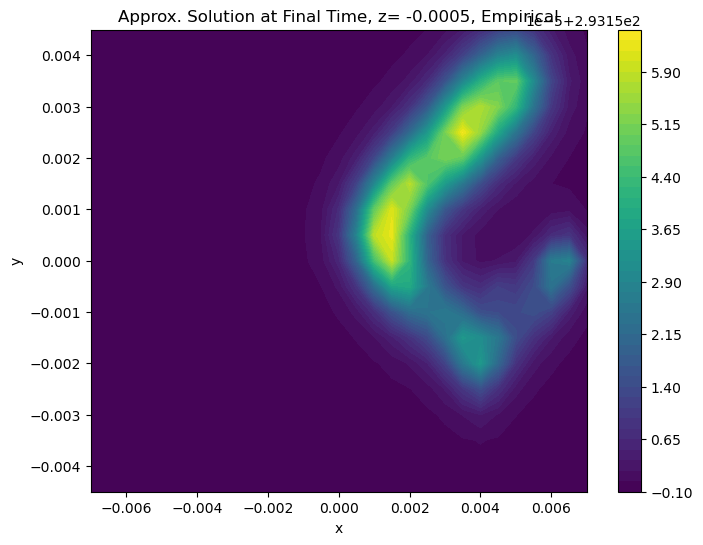

In [71]:
plt.figure(figsize=(8, 6))


x = torch.linspace(x_min, x_max, n_x, device=device)
y = torch.linspace(y_min, y_max, n_y, device=device)
z = torch.linspace(z_min, z_max, n_z, device=device)
X_int, Y_int = torch.meshgrid(x[1:-1],y[1:-1])

omega  = w_approx[:N_domain_tot,-1]

w_approx_1 =  omega[idx_1].reshape(n_x-2,n_y-2)

plt.figure(figsize=(8, 6))
cp2 = plt.contourf(X_int, Y_int, w_approx_1, levels=50, cmap='viridis')
plt.colorbar(cp2)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Approx. Solution at Final Time, z= -0.0005, Empirical')
plt.show()

<Figure size 800x600 with 0 Axes>

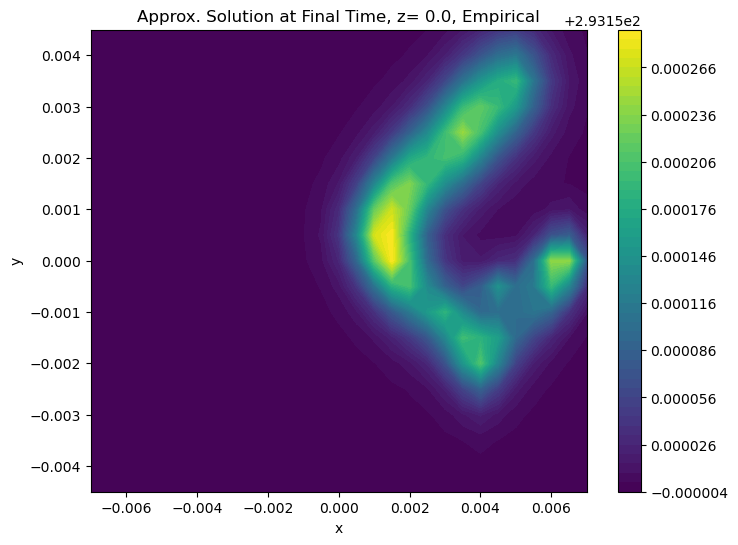

In [72]:
plt.figure(figsize=(8, 6))
X_int, Y_int = torch.meshgrid(x[1:-1],y[1:-1])

w_approx_2 =  omega[idx_2].reshape(n_x-2,n_y-2)

plt.figure(figsize=(8, 6))
cp2 = plt.contourf(X_int, Y_int, w_approx_2, levels=50, cmap='viridis')
plt.colorbar(cp2)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Approx. Solution at Final Time, z= 0.0, Empirical')
plt.show()

<Figure size 800x600 with 0 Axes>

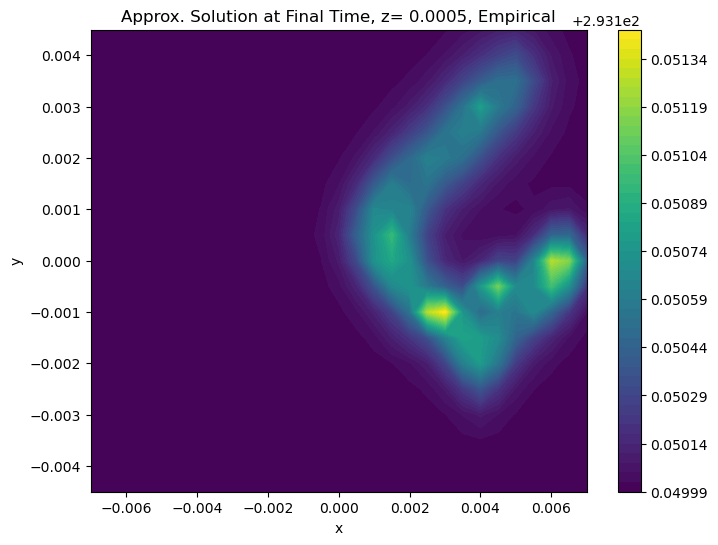

In [73]:
plt.figure(figsize=(8, 6))
X_int, Y_int = torch.meshgrid(x[1:-1],y[1:-1])

w_approx_3 =  omega[idx_3].reshape(n_x-2,n_y-2)

plt.figure(figsize=(8, 6))
cp2 = plt.contourf(X_int, Y_int, w_approx_3, levels=50, cmap='viridis')
plt.colorbar(cp2)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Approx. Solution at Final Time, z= 0.0005, Empirical')
plt.show()

<Figure size 800x600 with 0 Axes>

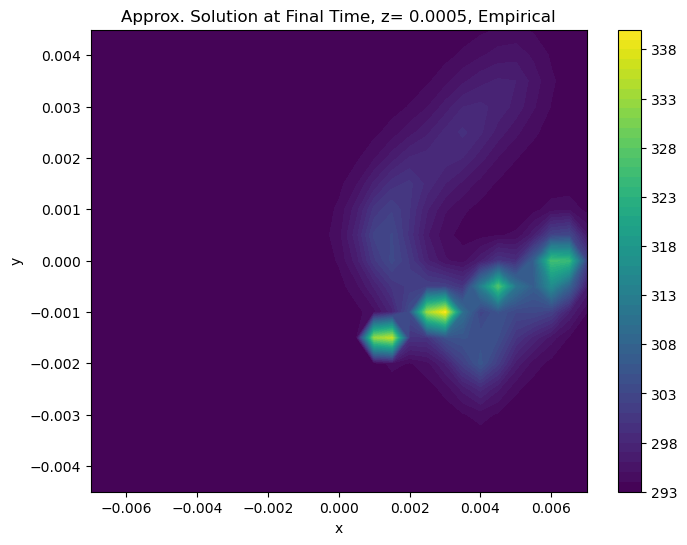

In [117]:
plt.figure(figsize=(8, 6))
X_int, Y_int = torch.meshgrid(x[1:-1],y[1:-1])

plt.figure(figsize=(8, 6))
cp2 = plt.contourf(X_int, Y_int, heat_sol[0,gamma_top_idx,-1].reshape(31,21)[1:-1,1:-1], levels=50, cmap='viridis')
plt.colorbar(cp2)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Approx. Solution at Final Time, z= 0.0005, Empirical')
plt.show()

In [114]:
heat_int[0,gamma_top_idx,-1]

IndexError: index 1654 is out of bounds for dimension 0 with size 1653

In [87]:
heat_int.shape

torch.Size([100, 1653, 129])

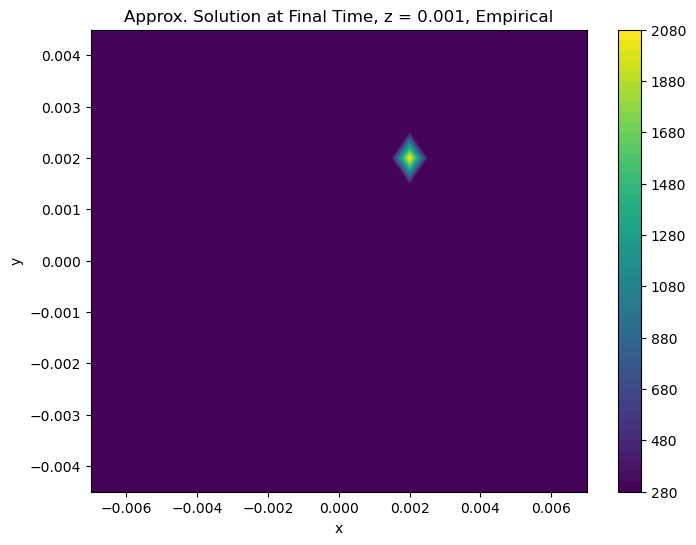

In [74]:

# --- 1. Build grid for plotting (on CPU for matplotlib) ---
x_cpu = torch.linspace(x_min, x_max, n_x)
y_cpu = torch.linspace(y_min, y_max, n_y)
X_int, Y_int = torch.meshgrid(x_cpu[1:-1], y_cpu[1:-1], indexing="ij")

# --- 2. Use final-time interior fields (old_y* after the loop) ---
y0 = old_y0               # (N_domain_tot,)
y1 = old_y1
y2 = old_y2
y3 = old_y3
y4 = old_y4
y_top_prev = old_y_top    # top values from the last step

t_final = M_t * dt
q_top = smooth_zigzag_flux(Gamma_top[:, :2], t,paths_x=paths_x, paths_y=paths_y, velocity=0.3, power=10.0, sigma=sigma_beam).to(device=device, dtype=w_approx.dtype)
T_below_full = extend_T_below_to_boundary(y0[gamma_below_idx].reshape(n_x-2,n_y-2), n_x, n_y)
y_top = newton_top_from_Tbelow(T_below_full.flatten(), q_top, dz, max_iter=5, tol=1e-6)



# Top is on full (n_x, n_y) grid
top_T_grid = y_top.reshape(n_x, n_y)

# --- 5. Plot interior of top layer ---
plt.figure(figsize=(8, 6))
cp2 = plt.contourf(
    X_int.numpy(), Y_int.numpy(),
    top_T_grid[1:-1, 1:-1].detach().cpu().numpy(),
    levels=50, cmap='viridis'
)
plt.colorbar(cp2)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Approx. Solution at Final Time, z = 0.001, Empirical')
plt.show()

In [75]:
import torch
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# ============================================================
# 0. Basic grid & indices
# ============================================================
device = w_approx.device

# full 1D grids (CPU for plotting)
x_cpu = torch.linspace(x_min, x_max, n_x)
y_cpu = torch.linspace(y_min, y_max, n_y)
z_cpu = torch.linspace(z_min, z_max, n_z)

# interior plotting grid (ignore outer boundary in x,y)
X_int, Y_int = torch.meshgrid(x_cpu[1:-1], y_cpu[1:-1], indexing="ij")
extent = [x_cpu[1].item(),  x_cpu[-2].item(),
          y_cpu[1].item(),  y_cpu[-2].item()]

# indices of interior points at three z-levels
Xz = X_domain_tot[:, 2]       # z-coordinates of interior nodes
idx_1 = torch.nonzero(Xz == z_cpu[1], as_tuple=True)[0]  # bottom interior layer
idx_2 = torch.nonzero(Xz == z_cpu[2], as_tuple=True)[0]  # middle interior layer
# top layer will be reconstructed via kernel, so no idx_3

# time info
num_frames = M_t + 1
times = torch.arange(num_frames, dtype=torch.float64) * dt

# interior T history (shape: N_domain_tot × (M_t+1))
T_all = w_approx[:N_domain_tot, :]   # just the T block

# global color range (shared by all three animations)
vmin = float(T_all.min().cpu())
vmax = float(T_all.max().cpu())


# ============================================================
# 1. Bottom and middle slices: pure FD slices
# ============================================================
def make_fd_slice_animation(idx_slice, z_value, title_prefix, filename=None):
    fig, ax = plt.subplots(figsize=(6, 5))

    # initial frame (n = 0)
    T0 = T_all[:, 0]
    Z0 = T0[idx_slice].reshape(n_x - 2, n_y - 2).detach().cpu().numpy()

    img = ax.imshow(
        Z0.T, origin="lower", extent=extent,
        vmin=vmin, vmax=vmax, cmap="viridis", aspect="auto"
    )
    cbar = fig.colorbar(img, ax=ax)
    cbar.set_label("Temperature")

    time_text = ax.text(0.02, 0.95, "", transform=ax.transAxes, color="w")
    ax.set_xlabel("x")
    ax.set_ylabel("y")

    def update(frame):
        Tn = T_all[:, frame]
        Z  = Tn[idx_slice].reshape(n_x - 2, n_y - 2).detach().cpu().numpy()
        t  = times[frame].item()

        img.set_data(Z.T)
        ax.set_title(f"{title_prefix} (z = {z_value:.4f}), t = {t:.4f} s")
        time_text.set_text(f"t = {t:.4f} s")
        return img, time_text

    anim = FuncAnimation(fig, update, frames=num_frames, interval=50, blit=False)

    if filename is not None:
        anim.save(filename, fps=15, dpi=150)

    plt.close(fig)
    return anim

anim_bottom = make_fd_slice_animation(
    idx_slice=idx_1,
    z_value=float(z_cpu[1]),
    title_prefix="Approx. solution (bottom slice)"
)

anim_middle = make_fd_slice_animation(
    idx_slice=idx_2,
    z_value=float(z_cpu[2]),
    title_prefix="Approx. solution (middle slice)"
)


anim_second_top = make_fd_slice_animation(
    idx_slice=idx_3,
    z_value=float(z_cpu[3]),
    title_prefix="Approx. solution (second top slice)"
)


# ============================================================
# 2. Top slice: **generalized kernel interpolation** each time
# ============================================================

def compute_top_layer_kernel(frame):
    """
    Reconstruct T on Gamma_top at time index `frame` using generalized
    kernel interpolation, exactly mirroring your top_predict + Neumann BC.
    """
    t = times[frame].item()

    # interior blocks at time n (= frame)
    y0 = w_approx[:N_domain_tot, frame]                       # T^n

    q_top = smooth_zigzag_flux(Gamma_top[:, :2], t,paths_x=paths_x, paths_y=paths_y, velocity=0.3, power=10.0, sigma=sigma_beam).to(device=device, dtype=w_approx.dtype)
    T_below_full = extend_T_below_to_boundary(y0[gamma_below_idx].reshape(n_x-2,n_y-2), n_x, n_y)
    y_top = newton_top_from_Tbelow(T_below_full.flatten(), q_top, dz, max_iter=5, tol=1e-6)

    top_T_grid = y_top.reshape(n_x, n_y)                      # full grid

    # return interior (exclude x,y boundary) as NumPy
    return top_T_grid[1:-1, 1:-1].detach().cpu().numpy()


def make_top_kernel_animation(title_prefix, filename=None):
    fig, ax = plt.subplots(figsize=(6, 5))

    # initial frame
    Z0 = compute_top_layer_kernel(0)
    img = ax.imshow(
        Z0.T, origin="lower", extent=extent,
        vmin=vmin, vmax=vmax, cmap="viridis", aspect="auto"
    )
    cbar = fig.colorbar(img, ax=ax)
    cbar.set_label("Temperature")

    time_text = ax.text(0.02, 0.95, "", transform=ax.transAxes, color="w")
    ax.set_xlabel("x")
    ax.set_ylabel("y")

    z_top_val = float(z_cpu[-1])

    def update(frame):
        Z = compute_top_layer_kernel(frame)
        t = times[frame].item()

        img.set_data(Z.T)
        ax.set_title(f"{title_prefix} (z = {z_top_val:.4f}), t = {t:.4f} s")
        time_text.set_text(f"t = {t:.4f} s")
        return img, time_text

    anim = FuncAnimation(fig, update, frames=num_frames, interval=50, blit=False)

    if filename is not None:
        anim.save(filename, fps=15, dpi=150)

    plt.close(fig)
    return anim

anim_top = make_top_kernel_animation(
    title_prefix="Approx. solution (kernel top slice), Matern"
)

# ============================================================
# 3. Display in Jupyter
# ============================================================
# Show one at a time in the notebook:
# HTML(anim_bottom.to_jshtml())
# HTML(anim_middle.to_jshtml())
# HTML(anim_top.to_jshtml())

# Or save to disk:
anim_bottom.save("bottom_slice.mp4", fps=15, dpi=150)
anim_middle.save("middle_slice.mp4", fps=15, dpi=150)
anim_second_top.save("second_top_slice.mp4", fps=15, dpi=150)
anim_top.save("top_slice_kernel.mp4", fps=15, dpi=150)